## Load Packages

In [35]:
using Revise 
using RxInfer
using Plots
using Random, LinearAlgebra, SpecialFunctions, StableRNGs, DomainSets, LaTeXStrings , StatsFuns, FStrings
using Optim, ForwardDiff, Distributions, Flux
using KernelFunctions, MAT, LoopVectorization
import KernelFunctions: SqExponentialKernel, Matern52Kernel, with_lengthscale, Kernel, kernelmatrix, spectral_mixture_kernel
using JLD
using RxGP
plotlyjs();

## Generate Data

In [46]:
# "Training Data";
Random.seed!(3)
xmin, xmax = -4, 4  # Bounds of the data
N = 30 # Number of samples
xtrain = sort(rand(Uniform(xmin, xmax), N))
xtrain_vv = [[xtrain[i]] for i in 1:N]
xtest_plot = collect(range(xmin-6, xmax+6; length=600))
xtest_plot_vv = [[xtest_plot[i]] for i in 1:length(xtest_plot)]
xtest_smse = collect(range(xmin, xmax; length=600))
xtest_smse_vv = [[xtest_smse[i]] for i in 1:length(xtest_smse)]
precision = 100
ytrain = sinc.(xtrain) + randn(N) * sqrt(1/precision)
ytrain_vv = [[ytrain[i]] for i in 1:N]
ωtrain = cosc.(xtrain) + randn(N) * sqrt(1/precision)
ωtrain_vv = [[ωtrain[i]] for i in 1:N]
f_true_plot = sinc.(xtest_plot)
gf_true_plot = cosc.(xtest_plot)
f_true_smse = sinc.(xtest_smse)
gf_true_smse = cosc.(xtest_smse)

# "Inducing Points";
Nu = 20; # number of inducing points
Xu = [[collect(range(-4,4; length=Nu))[i]] for i in 1:Nu];

## Plot Data

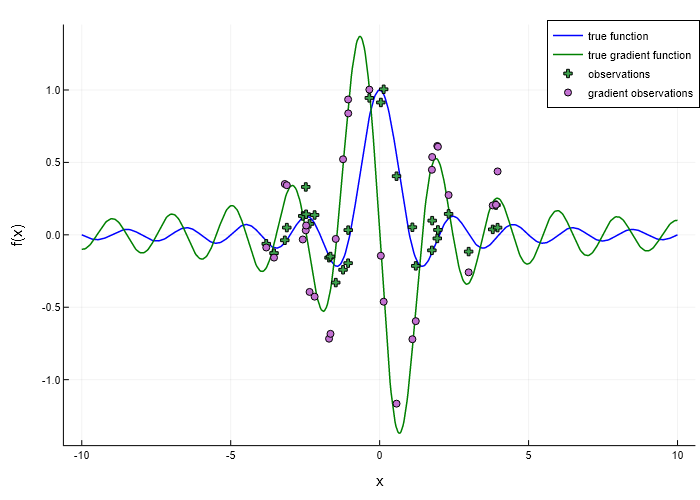

In [47]:
"Data visualization";
plot(xtest_plot, f_true_plot, linewidth=1.5, label="true function", color =:blue)
plot!(xtest_plot, gf_true_plot, linewidth=1.5, label="true gradient function", color =:green)
scatter!(xtrain, ytrain, alpha=1, label="observations", ms=3.5, marker=:cross, legend=:topright)
scatter!(xtrain, ωtrain, alpha=1, label="gradient observations", ms=3.5, marker=:circle, legend=:topright)
xlabel!("x")
ylabel!("f(x)")

## Configure GP

In [23]:
optimize_kθ = true
gpcache = GPCache()
optimizer = Flux.AdaMax(0.001, (0.9, 0.999))
D = size(Xu[1], 1)
mean_fn = (x) -> 1.0 # E.g. 0.0, 1.0, [x], dot(x,x)
method = ghcubature(21)

# KernelFunctions.jl kernel definition - Available specs: SE, SEn, SMn, SEn_SMn";
kernel_spec = Symbol(:SEn)
independent_SE_lengthscales = true  # Only used if kernel_spec is :SE, :SEn, or :SEn_SMn
kernel, θ_init, dim_θ = get_simple_kernel_and_params(D; kernel_spec=kernel_spec, num_SE=3, num_SM=3, independent_SE_lengthscales=independent_SE_lengthscales)
mode = Symbol(:AD)  # :AD or :AN - no AN for SM kernels
state = Flux.setup(optimizer, θ_init)
;

## Setup Model

In [24]:
# ======= Use gradient observations for training and optimization? ======= #
use_gradient_measurements_training = true
use_gradient_measurements_optimization = true # recommend to use with value measurements too - gradients alone cannot define a function

@model function gp_regression(y, ω, x, Xu, θ, qv_params, qw_params, qWg_params)
    # ---------------- Priors ---------------- #
    v ~ MvNormalWeightedMeanPrecision(qv_params...)
    w ~ GammaShapeRate(qw_params...)
    if use_gradient_measurements_training
        Wg ~ Wishart(qWg_params...)
    end

    # ---------------- Data ---------------- #
    for i in eachindex(x)
        y[i] ~ UniSGP(x[i], v, w, θ) 
        if use_gradient_measurements_training
            ω[i] ~ UniSGP_Grad(x[i], v, Wg, θ) 
        end
    end

end

gp_constraints = @constraints begin
    if use_gradient_measurements_training
        q(v, w, Wg) = q(v)q(w)q(Wg)
    else
        q(v, w) = q(v)q(w)
    end
end

@meta function GP_meta_inference(; Xu, θ)
    UniSGP() -> get_GP_meta(D; method=method, mean_fn=mean_fn, kernel=kernel, kernel_spec=kernel_spec, mode=mode, independent_SE_lengthscales=independent_SE_lengthscales, Xu=Xu, θ=θ)
    UniSGP_Grad() -> get_GP_meta(D; method=method, mean_fn=mean_fn, kernel=kernel, kernel_spec=kernel_spec, mode=mode, independent_SE_lengthscales=independent_SE_lengthscales, Xu=Xu, θ=θ)
end

@initialization function gp_init(; qv_params, qw_params, qWg_params)
    q(v) = MvNormalWeightedMeanPrecision(qv_params...)
    q(w) = GammaShapeRate(qw_params...)
    if use_gradient_measurements_training
        q(Wg) = Wishart(qWg_params...)
    end
end
;

## Setup Inference

In [25]:
function my_free_energy(θ; iterations=1, qv, qw, qWg)
    infer_result = infer(
        model = gp_regression(Xu=Xu, θ=θ, qv_params=BayesBase.params(qv), qw_params=BayesBase.params(qw), qWg_params=BayesBase.params(qWg)),
        iterations = iterations,
        data = (y=ytrain, ω=ωtrain_vv, x=xtrain_vv),
        initialization = gp_init(qv_params=BayesBase.params(qv), qw_params=BayesBase.params(qw), qWg_params=BayesBase.params(qWg)),
        constraints = gp_constraints,
        returnvars = use_gradient_measurements_training ? (v=KeepLast(), w=KeepLast(), Wg=KeepLast()) : (v=KeepLast(), w=KeepLast()),
        meta = GP_meta_inference(Xu=Xu, θ=θ),
        free_energy = true,
    )    
    if use_gradient_measurements_training
        return (infer_result.free_energy[end], infer_result.posteriors[:v], infer_result.posteriors[:w], infer_result.posteriors[:Wg])
    else
        return (infer_result.free_energy[end], infer_result.posteriors[:v], infer_result.posteriors[:w], nothing)
    end
end

function PerformInference(θ; iterations=1, runs=1, epochs=1)
    FE_value = []
    q_v = []
    q_w = []
    q_Wg = []
    θ_ = []
    qv = MvNormalWeightedMeanPrecision(mean_fn.(Xu), 50diageye(Nu))
    qw = GammaShapeRate(1e-2, 1e-2)
    qWg = Wishart(D, (1/D)*diageye(D))
    θ_optimal = deepcopy(θ)
    grad = similar(θ)
    Ex = get_Ex(;mean_fn=mean_fn)
    Fxθ = get_Fxθ(D; kernel=kernel, kernel_spec=kernel_spec, mode=mode)
    Dxθ = get_Dxθ(D; kernel=kernel, kernel_spec=kernel_spec, mode=mode, independent_SE_lengthscales=independent_SE_lengthscales)
    Cxθ_Xu = get_Cxθ_Xu(D; kernel=kernel, kernel_spec=kernel_spec, mode=mode, independent_SE_lengthscales=independent_SE_lengthscales)

    for run=1:runs
        #step 1: Perform inference for v, w 
        fe, qv, qw, qWg = my_free_energy(θ_optimal; iterations=iterations, qv=qv, qw=qw, qWg=qWg)

        #step 2: optimize the hyperparameters 
        if optimize_kθ    
            for epoch=1:epochs
                grad_llh_default!(grad, θ_optimal;
                    y_data=ytrain, 
                    x_data=xtrain_vv, 
                    ω_data=use_gradient_measurements_optimization ? ωtrain_vv : nothing, 
                    qv=qv, qw=qw, qWg=qWg, kernel=kernel, Ex=Ex, Dxθ=Dxθ, Cxθ_Xu=Cxθ_Xu, mean_fn=mean_fn, Xu=Xu)
                Flux.Optimise.update!(state, θ_optimal, grad)
            end
        end

        #step 3: store the results
        append!(FE_value, fe)
        push!(q_v, qv)
        push!(q_w, qw)
        push!(q_Wg, qWg)
        push!(θ_, deepcopy(θ_optimal))
    end

    return q_v, q_w, q_Wg, FE_value, θ_optimal, θ_
end

PerformInference (generic function with 1 method)

## Run Inference

In [26]:
q_v, q_w, q_Wg, FE_value, θ_optimal, θ_ = PerformInference(θ_init; iterations=10, runs=10, epochs=10);

In [27]:
qv = q_v[end]
qw = q_w[end]
qWg = use_gradient_measurements_training ? q_Wg[end] : nothing
;
# q_v, q_Wg, FE_value, θ_optimal = nothing, nothing, nothing, nothing;

In [28]:
# # To save the parameter results
# save("../savefiles/gp_regression_qv.jld","qv",qv)
# save("../savefiles/gp_regression_qw.jld","qw",qw)
# save("../savefiles/gp_regression_qWg.jld","qWg",qWg)
# save("../savefiles/gp_regression_θ.jld","θ",θ_optimal)

# # If you can't wait, then load the optimal results
# qv = load("../savefiles/gp_regression_qv.jld")["qv"]
# qw = load("../savefiles/gp_regression_qw.jld")["qw"]
# qWg = load("../savefiles/gp_regression_qWg.jld")["qWg"]
# θ_opt = load("../savefiles/gp_regression_θ.jld")["θ"];

## Plot Inference Results

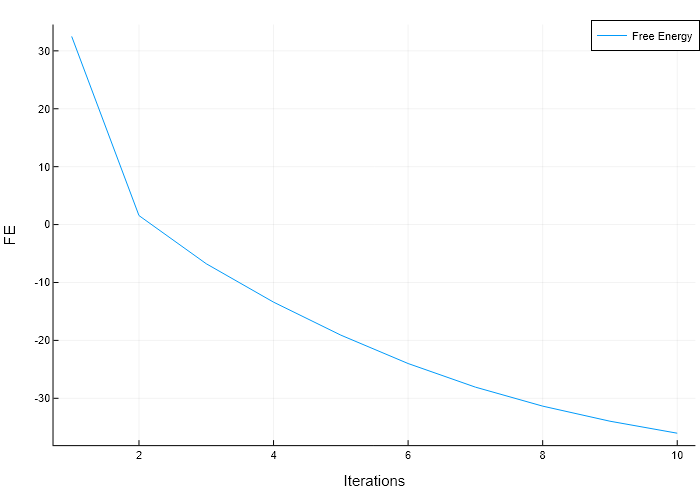

In [29]:
plot(FE_value, label = "Free Energy", xlabel = "Iterations", ylabel="FE", legend=:topright)

Optimal θ: [1.105980647281476, 0.9796376444289979, 1.0381014740017838, 0.963381646724313, 0.986583072467522, 0.9971147477631496]


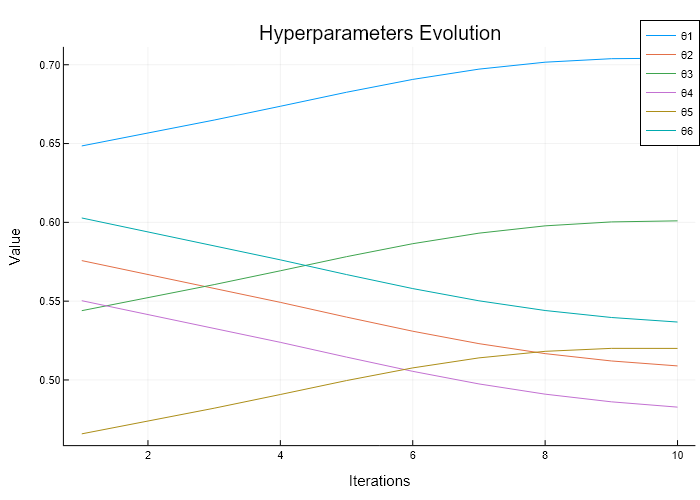

In [30]:
θ_matrix = hcat(θ_...)' # Convert θ_list to matrix form for plotting
plot(θ_matrix[:,1],label = "θ1",
            xlabel = "Iterations",
            ylabel = "Value",
            title = "Hyperparameters Evolution",
            legend=:topright,)
for i in 2:size(θ_matrix, 2)
    plot!(θ_matrix[:,i],label = "θ$i")
end
print("Optimal θ: ", StatsFuns.softplus.(θ_optimal), "\n")
plot!()

## Plot Prediction Results

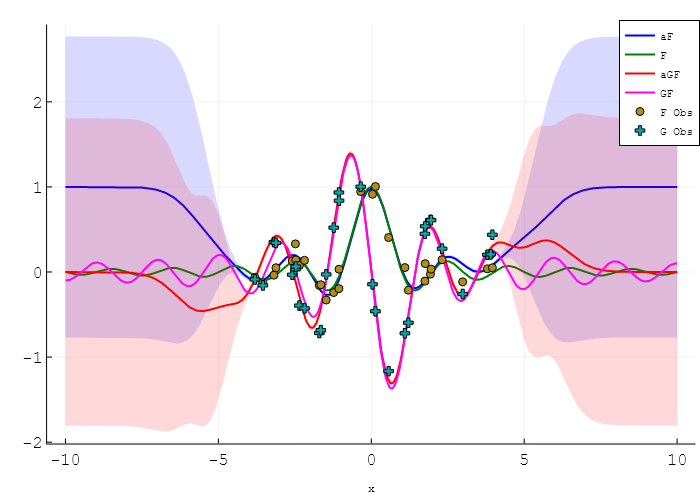

In [48]:
_m_j_plot, _C_j_plot = predict_GP_joints(m_in=xtest_plot_vv, q_v=qv, q_θ=θ_optimal, meta=get_GP_meta(D; method=method, mean_fn=mean_fn, kernel=kernel, kernel_spec=kernel_spec, mode=mode, independent_SE_lengthscales=independent_SE_lengthscales, Xu=Xu, θ=θ_optimal))
predict_value_mean_plot = _m_j_plot[:, 1]
predict_value_var_plot = _C_j_plot[:, 1, 1]
predict_grad_mean_plot = _m_j_plot[:, 2]
predict_grad_var_plot = _C_j_plot[:, 2, 2]
plot(xtest_plot, predict_value_mean_plot, tickfontsize=12, ribbon = sqrt.(predict_value_var_plot),
    label="aF", lw=2, legend=:topright, color=:blue, fillalpha=0.15, fontfamily="monospace",legendfontsize=8, guidefontsize=8)
plot!(xtest_plot, f_true, label="F", lw=2, color=:green)
plot!(xtest_plot, predict_grad_mean_plot, tickfontsize=12, ribbon = sqrt.(predict_grad_var_plot),
    label="aGF", lw=2, legend=:topright, color=:red, fillalpha=0.15, fontfamily="monospace",legendfontsize=8, guidefontsize=8)
plot!(xtest_plot, gf_true,label="GF", lw=2, color=:magenta)
scatter!(xtrain, ytrain, label="F Obs",  alpha=1, ms=4, marker=:circle)
scatter!(xtrain, ωtrain, label="G Obs",  alpha=1, ms=4, marker=:cross)
xlabel!("x")

In [32]:
# # save plot
# savefig("..\\savefiles\\kernel_hyperparameter_optimization\\1SM_SE\\grad.png")

In [50]:
# standardized mean squared error (for regression)
function SMSE(y_true, y_approx)
    N = length(y_true)
    mse = norm(y_true - y_approx)^2 / N 
    return mse / var(y_true)
end
_m_j_smse, _ = predict_GP_joints(m_in=xtest_smse_vv, q_v=qv, q_θ=θ_optimal, meta=get_GP_meta(D; method=method, mean_fn=mean_fn, kernel=kernel, kernel_spec=kernel_spec, mode=mode, independent_SE_lengthscales=independent_SE_lengthscales, Xu=Xu, θ=θ_optimal))
predict_value_mean_smse = _m_j_smse[:, 1]
predict_grad_mean_smse = _m_j_smse[:, 2]
println("SMSE value of SGP node: ", SMSE(f_true_smse, predict_value_mean_smse))
println("SMSE value of SGP gradient node: ", SMSE(gf_true_smse, predict_grad_mean_smse))
println("FE_value start and finish: ", FE_value[1], " ", FE_value[end])
println("θ_optimal: ", θ_optimal)

SMSE value of SGP node: 0.026555187988820953
SMSE value of SGP gradient node: 0.01979200681967787
FE_value start and finish: 32.48973482156839 -36.02917629195622
θ_optimal: [0.70417945822235, 0.5089183678706081, 0.6009500724532161, 0.4827614375764406, 0.5200159105618214, 0.536756612631227]


## Debug Update Rules

In [34]:
# "Need fake-data for :in, :out, :v, :w, :Wg, :θ

# :in PointMass
# :out_y PointMass
# :out_ω PointMass
# :v MvNormalMeanCovariance
# :w GammaShapeRate
# :Wg Wishart
# :θ PointMass
# "

# Univariate Input
D = 1
Nu = 20; # number of inducing points
Xu_test = [[randn()] for _ in 1:Nu]
in_test = PointMass([0.1])
y_out_test = PointMass(3.6)
ω_out_test = PointMass([0.1])
v_test = MvNormalMeanCovariance(apply_mean_fn.(Xu_test, mean_fn), 50.0 * Matrix(I, Nu, Nu))
w_test = GammaShapeRate(1e-2, 1e-2)
Wg_test = Wishart(1, (1/3) * diageye(1))
θ_test = PointMass(θ_init)

# # Multivariate input
# D_test = 2
# Nu = 20; # number of inducing points
# Xu_test = [[randn() for _ in 1:D_test] for _ in 1:Nu]
# in_test = PointMass([0.1 for _ in 1:D_test])
# y_out_test = PointMass(3.6)
# ω_out_test = PointMass([0.1 for _ in 1:D_test])
# v_test = MvNormalMeanCovariance(apply_mean_fn.(Xu_test, mean_fn), 50.0 * Matrix(I, Nu, Nu))
# w_test = GammaShapeRate(1e-2, 1e-2)
# Wg_test = Wishart(D_test, (1/3) * diageye(D_test))
# # θ_test = PointMass(θ_init);

kernel_test = deepcopy(kernel)
θ_test = PointMass(deepcopy(θ_init));

function debug_rules_UniSGP_Grad(in_test, y_out_test, ω_out_test, v_test, w_test, Wg_test, θ_test; meta=get_GP_meta(D; method=method, mean_fn=mean_fn, kernel=kernel_test, kernel_spec=kernel_spec, mode=mode, independent_SE_lengthscales=independent_SE_lengthscales, Xu=Xu_test, θ=mean(θ_test)))
    _ = @call_rule UniSGP(:out, Marginalisation) (q_in=in_test, q_v=v_test, q_w=w_test, q_θ=θ_test, meta=meta)
    _ = @call_rule UniSGP(:in, Marginalisation) (q_out=y_out_test, q_v=v_test, q_w=w_test, q_θ=θ_test, meta=meta)
    _ = @call_rule UniSGP(:v, Marginalisation) (q_out=y_out_test, q_in=in_test, q_w=w_test, q_θ=θ_test, meta=meta)
    _ = @call_rule UniSGP(:w, Marginalisation) (q_out=y_out_test, q_in=in_test, q_v=v_test, q_θ=θ_test, meta=meta)
    _ = @call_rule UniSGP(:θ, Marginalisation) (q_out=y_out_test, q_in=in_test, q_v=v_test, q_w=w_test, meta=meta)

    _ = @call_rule UniSGP_Grad(:out, Marginalisation) (q_in=in_test, q_v=v_test, q_Wg=Wg_test, q_θ=θ_test, meta=meta)
    _ = @call_rule UniSGP_Grad(:in, Marginalisation) (q_out=ω_out_test, q_v=v_test, q_Wg=Wg_test, q_θ=θ_test, meta=meta)
    _ = @call_rule UniSGP_Grad(:v, Marginalisation) (q_out=ω_out_test, q_in=in_test, q_Wg=Wg_test, q_θ=θ_test, meta=meta)
    _ = @call_rule UniSGP_Grad(:Wg, Marginalisation) (q_out=ω_out_test, q_in=in_test, q_v=v_test, q_θ=θ_test, meta=meta)
    _ = @call_rule UniSGP_Grad(:θ, Marginalisation) (q_out=ω_out_test, q_in=in_test, q_v=v_test, q_Wg=Wg_test, meta=meta)
end

debug_rules_UniSGP_Grad(in_test, y_out_test, ω_out_test, v_test, w_test, Wg_test, θ_test)

ContinuousMultivariateLogPdf(UnspecifiedDomain())